<a href="https://colab.research.google.com/github/alezakuskin/Stark_ML/blob/Temperature-tuning/Main_body.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# StarkML: Machine Learning-based Tool for Predicting Stark Parameters of Atomic Emission Lines

# Imports

In [1]:
#!pip install pytorch-tabnet
#!git clone -b Ions https://github.com/alezakuskin/Stark_ML

In [ ]:
# import smtplib
# def send_email(message):
#     smtpObj = smtplib.SMTP('smtp.gmail.com', 587)
#     smtpObj.starttls()
#     smtpObj.login('alezakuskin2407@gmail.com','yaic qsvs nmwd iysf')
#     smtpObj.sendmail("alezakuskin2407@gmail.com", 'ale-zakuskin@yandex.ru', message)
#     smtpObj.quit()

In [120]:
RunInColab = 'google.colab' in str(get_ipython())
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

#Installing missing packages
!pip install optuna
!pip install xgboost
!pip install lightgbm
!pip install roman

#Imports
import os
import joblib
import stat
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import time
import importlib
import json
import torch
import lightgbm
#torch.autograd.set_detect_anomaly(False)
#torch.set_default_tensor_type(torch.DoubleTensor)
#torch.set_default_dtype(torch.float64)

#Importing sklearn models and metrics
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import svm
from sklearn.preprocessing import StandardScaler

#Importing TabNet Regressor model    
#from pytorch_tabnet.tab_model import  TabNetRegressor

np.random.seed(777)

import pytorch_tabnet
'''os.environ['tabnet'] = pytorch_tabnet.__path__.__dict__['_path'][0]
os.environ['patchfile'] = os.path.abspath(os.path.join('Stark_ML', 'float64.patch'))
if os.name == 'nt':
    !cd /d %tabnet% & patch < "%patchfile%"
else:
    !cd $tabnet && patch -f < $patchfile
importlib.reload(pytorch_tabnet)'''

if RunInColab:
    from google.colab import output
    def clear_output():
        output.clear()
else:
    from IPython import display
    def clear_output():
        display.clear_output()

clear_output()

In [121]:
#Download and import all utilities and models
'''if os.path.isdir('Stark_ML'):
    import Stark_ML
    def remove_readonly(func, path, _):
            os.chmod(path, stat.S_IWRITE)
            func(path)
    shutil.rmtree(Stark_ML.__path__.__dict__['_path'][0], onerror = remove_readonly)

!git clone -b Ions https://github.com/alezakuskin/Stark_ML'''

import Stark_ML
import Stark_ML.utils.optuning
import Stark_ML.models.base_models
import Stark_ML.utils.metrics
import Stark_ML.utils.terms
import Stark_ML.utils.testset
import Stark_ML.utils.plotting
import Stark_ML.models.tabnet

importlib.reload(Stark_ML.models.base_models)
importlib.reload(Stark_ML.utils.optuning)
importlib.reload(Stark_ML.utils.metrics)
importlib.reload(Stark_ML.utils.plotting)
importlib.reload(Stark_ML.models.tabnet)

from Stark_ML.models.base_models import *
from Stark_ML.utils.optuning import *
from Stark_ML.utils.metrics import *
from Stark_ML.utils.terms import *
from Stark_ML.utils.testset import *
from Stark_ML.utils.plotting import *
from Stark_ML.models.tabnet import *
from Stark_ML.utils import *
from pytorch_tabnet.tab_model import  TabNetRegressor

new_rc_params = {'text.usetex': False,
                "svg.fonttype": 'none'
                }
plt.rcParams.update(new_rc_params)


clear_output()

# Data preprocessing

In [122]:
#Import data for training and testing
data_a = pd.read_excel(Stark_ML.__path__.__dict__['_path'][0] + '/Source_files/Stark_data.xlsx',
                     sheet_name='Experimental',
                     usecols='A:BF'
                   )
#Replace term symbols with quantum numbers
data_a['Term'] = term_to_number(data_a['Term'])
data_a['Term.1'] = term_to_number(data_a['Term.1'])

#Replace accuracy symbols with uncetrainty in %
data_a['w error (%)'] = uncertainty_to_number(data_a[data_a['w error (%)'].notna()]['w error (%)'])
data_a['d error (%)'] = uncertainty_to_number(data_a[data_a['d error (%)'].notna()]['d error (%)'])

In [123]:
#Import ions data for training and testing
data_i = pd.read_excel(Stark_ML.__path__.__dict__['_path'][0] + '/Source_files/Stark_data.xlsx',
                     sheet_name='Ions',
                     usecols='A:BQ'
                   )
#Replace term symbols with quantum numbers
data_i['Term'] = term_to_number(data_i['Term'])
data_i['Term.1'] = term_to_number(data_i['Term.1'])

#Replace accuracy symbols with uncetrainty in %
data_i['w error (%)'] = uncertainty_to_number(data_i[data_i['w error (%)'].notna()]['w error (%)'])
data_i['d error (%)'] = uncertainty_to_number(data_i[data_i['d error (%)'].notna()]['d error (%)'])

#Drop entries with levels' data unavailable
data_i = data_i[data_i['J'].notna()]
data_i = data_i[data_i['J.1'].notna()]

In [124]:
#Making sure that atoms and ions datasets have the same set of columns
for i, name in enumerate(data_i.columns):
    if name != data_a.columns[i]:
        if name in data_a.columns:
            print(f'renaming {name}')
            data_a = data_a.rename(columns = {name: name+'.1'})
        data_a.insert(i, data_i.columns[i], 0)
        print(data_i.columns[i])

Charge
5f
5g
renaming 6d
6d
renaming 7p
7p
5f.1
5g.1
6f
6g
6h
11s


In [125]:
#Merging atoms and ions together
data = pd.concat([data_a, data_i], axis = 0, ignore_index = True)

#Incerting "gap to ionization energy" feature
data.insert(data.columns.get_loc('E upper')+1, 'Gap to ion', 0)
data['Gap to ion'] = gap_to_ion(data, 'E upper')

In [126]:
#Step 1.
#Exclude elements for testing
#Defining elements to exclude from training set
elements_to_exclude = ['S', 'Mg', 'Mn']

In [127]:
#Step 2.
#Creating data, targets and labels for the process of width prediction
data_width = data[data['w (A)'].isna() == False]
data_width_elements = data_width.loc[data_width['Element'].isin(elements_to_exclude)]
data_width = data_width.drop(data_width_elements.index)
data_width = data_width.sort_values(by=['Z number'])

#Separate targets from data
target_width = data_width['w (A)']
target_width_elements = data_width_elements['w (A)']

#Separate labels from data
label_width = data_width.loc[:, ['Element', 'Wavelength']]
label_width_elements = data_width_elements.loc[:, ['Element', 'Wavelength']]

#Remove width and shift values from data
data_width = data_width.drop(columns = ['d (A)', 'w (A)'])
data_width_elements = data_width_elements.drop(columns = ['d (A)', 'w (A)'])

#Remove uncertainty from data
data_width = data_width.drop(columns = ['w error (%)', 'd error (%)'])
data_width_elements = data_width_elements.drop(columns = ['w error (%)', 'd error (%)'])

In [128]:
#Step 3.
#Split into train and test by quartiles
#Q1
data_test_q1, target_test_q1 = test_selection(data_width,
                                              target_width,
                                              p = 0.137,
                                              low_limit = 'min',
                                              up_limit = 25,
                                              random_state = 7)
#Q2
data_test_q2, target_test_q2 = test_selection(data_width,
                                              target_width,
                                              p = 0.137,
                                              low_limit = 25,
                                              up_limit = 50,
                                              random_state = 7)
#Q3
data_test_q3, target_test_q3 = test_selection(data_width,
                                              target_width,
                                              p = 0.137,
                                              low_limit = 50,
                                              up_limit = 75,
                                              random_state = 7)
#Q4
target_test_q4 = pd.Series()
while len(target_test_q4[target_test_q4 > 150]) < 1 or len(target_test_q4[(target_test_q4 > 70) & (target_test_q4 < 150)]) < 1:
    data_test_q4, target_test_q4 = test_selection(data_width,
                                                target_width,
                                                p = 0.137,
                                                low_limit = 75,
                                                random_state = None)
#manually selected and fixed random state that gives the closest train and test distributios  
data_test_q4, target_test_q4 = test_selection(data_width,
                                                target_width,
                                                p = 0.137,
                                                low_limit = 75,
                                                random_state = 3)

#Combining quartiles into full test dataset
data_width_test, target_width_test = pd.concat([data_test_q1, data_test_q2]), pd.concat([target_test_q1, target_test_q2])
data_width_test, target_width_test = pd.concat([data_width_test, data_test_q3]), pd.concat([target_width_test, target_test_q3])
data_width_test, target_width_test = pd.concat([data_width_test, data_test_q4]), pd.concat([target_width_test, target_test_q4])

#Remove test entries from data -> get train set
data_width_train, target_width_train = data_width.drop(data_width_test.index), target_width.drop(target_width_test.index)

## -- *OPTIONAL*-- Atoms + ions data visual description

# Shift data preprocessing

In [129]:
#Create dataset with shift data
data_shift = data[data['d (A)'].isna() == False]

#Remove unneccessary columns (i.e. those with one value only)
columns_to_drop = []
for col in data_shift.columns:
    if data_shift[col].nunique() == 1:
        columns_to_drop.append(col)
data_shift = data_shift.drop(columns = columns_to_drop)

#Creating data, target and labels for shift prediction
data_shift_elements = data_shift.loc[data_shift['Element'].isin(elements_to_exclude)]
data_shift = data_shift.drop(data_shift_elements.index)
data_shift = data_shift.sort_values(by=['Z number'])

#Separate targets from data
target_shift = data_shift['d (A)']
target_shift_elements = data_shift_elements['d (A)']

#Separate labels from data
label_shift = data_shift.loc[:, ['Element', 'Wavelength']]
label_shift_elements = data_shift_elements.loc[:, ['Element', 'Wavelength']]

#Remove width and shift values from data
data_shift = data_shift.drop(columns = ['w (A)', 'd (A)'])
data_shift_elements = data_shift_elements.drop(columns = ['w (A)', 'd (A)'])

#Remove uncertainty from data
data_shift = data_shift.drop(columns = ['w error (%)', 'd error (%)'])
data_shift_elements = data_shift_elements.drop(columns = ['w error (%)', 'd error (%)'])

In [130]:
#Split into train and test by quartiles
#Q1
data_test_q1, target_test_q1 = test_selection(data_shift,
                                              target_shift,
                                              p = 0.135,
                                              low_limit = 'min',
                                              up_limit = 25,
                                              random_state = 6)

#Q2
data_test_q2, target_test_q2 = test_selection(data_shift,
                                              target_shift,
                                              p = 0.135,
                                              low_limit = 25,
                                              up_limit = 50,
                                              random_state = 6)

#Q3
data_test_q3, target_test_q3 = test_selection(data_shift,
                                              target_shift,
                                              p = 0.135,
                                              low_limit = 50,
                                              up_limit = 75,
                                              random_state = 6)

#Q4
target_test_q4 = pd.Series()
while len(target_test_q4[target_test_q4 > 17.5]) < 1 or len(target_test_q4[(target_test_q4 > 11.5) & (target_test_q4 < 17.5)]) < 1:
    data_test_q4, target_test_q4 = test_selection(data_shift,
                                                target_shift,
                                                p = 0.135,
                                                low_limit = 75,
                                                random_state = None)
  

#Merging full train and test datasets
data_shift_test, target_shift_test = pd.concat([data_test_q1, data_test_q2]), pd.concat([target_test_q1, target_test_q2])
data_shift_test, target_shift_test = pd.concat([data_shift_test, data_test_q3]), pd.concat([target_shift_test, target_test_q3])
data_shift_test, target_shift_test = pd.concat([data_shift_test, data_test_q4]), pd.concat([target_shift_test, target_test_q4])

data_shift_train, target_shift_train = data_shift.drop(data_shift_test.index), target_shift.drop(target_shift_test.index)

## -- *OPTIONAL*-- Shift data visual description 

# Both data preprocessing

In [131]:
#Create dataset with both data
data_both = data[(data['w (A)'].isna() == False) & (data['d (A)'].isna() == False)]

#Remove unneccessary columns (i.e. those with one value only)
columns_to_drop = []
for col in data_both.columns:
    if data_both[col].nunique() == 1:
        columns_to_drop.append(col)
data_both = data_both.drop(columns = columns_to_drop)

#Creating data, target and labels for shift prediction
data_both_elements = data_both.loc[data_both['Element'].isin(elements_to_exclude)]
data_both = data_both.drop(data_both_elements.index)
data_both = data_both.sort_values(by=['Z number'])

#Separate targets from data
target_both = data_both['d (A)']
target_both_elements = data_both_elements['d (A)']

#Separate labels from data
label_both = data_both.loc[:, ['Element', 'Wavelength']]
label_both_elements = data_both_elements.loc[:, ['Element', 'Wavelength']]

#Remove shift values from data
data_both = data_both.drop(columns = ['d (A)'])
data_both_elements = data_both_elements.drop(columns = ['d (A)'])

#Remove uncertainty from data
data_both = data_both.drop(columns = ['w error (%)', 'd error (%)'])
data_both_elements = data_both_elements.drop(columns = ['w error (%)', 'd error (%)'])

In [132]:
#Split into train and test
data_both_train, data_both_test, target_both_train, target_both_test = train_test_split(data_both,
                                                                                       target_both,
                                                                                       test_size = 0.114,
                                                                                       random_state = 6)

# Dataset modifications  (scaling, augmentation)

In [133]:
def unscale(y):
    return (np.exp(y) - 1) * epsilon

In [245]:
augmented_train_set = False#@param {type:"boolean"}
#@markdown Note: augmentation will be applied to width only 

#@markdown ---

#@markdown Select whether you'd like to work with 'width' or 'shift' predictions
parameter  = 'width' #@param ["width", "shift", "both"]

#@markdown ---

#@markdown You can enter any reasonable value less than 180 Angstrom to limit the upper boundary of width walues. (not recommended to change)
width_threshold =  200#@param {type:"number"}

#@markdown ---

#@markdown Scale target values by the formula: $y_{scaled} = ln(1 + \frac{y_{raw}}{\epsilon})$
scaled_target = True#@param {type:"boolean"}
epsilon = 1e-3#@param {type: "number"}

#@markdown ---

#@markdown Normalize energies by the ionization energy for each particle
normalized_energy = False#@param {type:"boolean"}

#@markdown ---

apply_scaler = False#@param {type:"boolean"}

In [246]:
def constr_train_test(parameter, augmented_train_set, scaled_target, normalized_energy, print_stats = True):
    #Applying 'width' or 'shift' or 'both' selection
    if parameter == 'width':
        X_train, Y_train = data_width_train.copy(), target_width_train.copy()
        X_test, Y_test = data_width_test.copy(), target_width_test.copy()
        X_elem, Y_elem, L_elem = data_width_elements.copy(), target_width_elements.copy(), label_width_elements.copy()
    elif parameter == 'shift':
        X_train, Y_train = data_shift_train.copy(), target_shift_train.copy()
        X_test, Y_test = data_shift_test.copy(), target_shift_test.copy()
        X_elem, Y_elem, L_elem = data_shift_elements.copy(), target_shift_elements.copy(), label_shift_elements.copy()
    elif parameter == 'both':
        X_train, Y_train = data_both_train.copy(), target_both_train.copy()
        X_test, Y_test = data_both_test.copy(), target_both_test.copy()
        X_elem, Y_elem, L_elem = data_both_elements.copy(), target_both_elements.copy(), label_both_elements.copy()
    else:
        raise NameError('Incorrect parameter name selected')

    #Handling augmentation
    if augmented_train_set:
        factor = 1.05
        X_train_aug, Y_train_aug = X_train.copy(), Y_train.copy()
        for index, row in X_train.iterrows():
            row['T'] = row['T']*factor
            X_train_aug = pd.concat([X_train_aug, row.to_frame().T], ignore_index=True)
            Y_train_aug = pd.concat([Y_train_aug, pd.Series(Y_train.loc[index])], ignore_index=True)

            row['T'] = row['T']/factor**2
            X_train_aug = pd.concat([X_train_aug, row.to_frame().T], ignore_index=True)
            Y_train_aug = pd.concat([Y_train_aug, pd.Series(Y_train.loc[index])], ignore_index=True)
        X_train_aug = X_train_aug.astype(X_train.dtypes.to_dict())    

        X_train, Y_train = X_train_aug, Y_train_aug
        X_test,  Y_test  = X_test, Y_test

    #Shuffling
    X_train = X_train.sample(frac = 1, random_state = 777)
    Y_train = Y_train.sample(frac = 1, random_state = 777)

    #Applying upper boundary to width values
#     if parameter == 'width':
#         X_train, Y_train = X_train.loc[Y_train.loc[Y_train < width_threshold].index], Y_train.loc[Y_train < width_threshold]
#         X_test,  Y_test  = X_test.loc[Y_test.loc[Y_test < width_threshold].index], Y_test.loc[Y_test < width_threshold]
#         X_elem,  Y_elem  = X_elem.loc[Y_elem.loc[Y_elem < width_threshold].index], Y_elem.loc[Y_elem < width_threshold]
#         L_elem = L_elem.loc[Y_elem.loc[Y_elem < width_threshold].index]
    
    #Applying scaling of targets
    if scaled_target:
        Y_train = np.log(1 + Y_train / epsilon)
        Y_test  = np.log(1 + Y_test / epsilon)
        Y_elem  = np.log(1 + Y_elem / epsilon)

    #Normalizing energies
    if normalized_energy:
        X_train['E lower'], X_train['E upper'] = energy_to_fraction(X_train, 'E lower'), energy_to_fraction(X_train, 'E upper')
        X_test['E lower'],  X_test['E upper']  = energy_to_fraction(X_test, 'E lower'), energy_to_fraction(X_test, 'E upper')
        X_elem['E lower'],  X_elem['E upper']  = energy_to_fraction(X_elem, 'E lower'), energy_to_fraction(X_elem, 'E upper')
        X_train['Gap to ion'] = energy_to_fraction(X_train, 'Gap to ion')
        X_test['Gap to ion'] = energy_to_fraction(X_test, 'Gap to ion')
        X_elem['Gap to ion'] = energy_to_fraction(X_elem, 'Gap to ion')

    #Removing unneccesary columns:
    X_train = X_train.drop(columns=['Element', 'Wavelength', 'Z number'])
    X_test  = X_test.drop(columns=['Element', 'Wavelength', 'Z number'])
    X_elem  = X_elem.drop(columns=['Element', 'Wavelength', 'Z number'])

    scaler = StandardScaler()
    scaler.fit(X_train)

    if print_stats:
        print(f'Selected parameter: {parameter} \n')
        if augmented_train_set:
            print(f'Total number of items with known {parameter}: {X_train.shape[0]/3 + X_test.shape[0] + X_elem.shape[0]}')
        else:
            print(f'Total number of items with known {parameter}: {X_train.shape[0] + X_test.shape[0] + X_elem.shape[0]}')

        print(f'Size of training set: {X_train.shape[0]}')
        print(f'Size of ttest set: {X_test.shape[0]}')
        print(f'Size of elements-exclusive test set: {X_elem.shape[0]}')
    
    return(X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler)

X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter,
                                                                                     augmented_train_set,
                                                                                     scaled_target,
                                                                                     normalized_energy)

Selected parameter: width 

Total number of items with known width: 6028
Size of training set: 4875
Size of ttest set: 772
Size of elements-exclusive test set: 381


# Models optimization

## Data for autoencoder

In [155]:
DB_data = pd.read_csv('C:\\Users\\Alex\\Documents\\GitHub\\All parsed from DB.csv')

DB_data_test, DB_target_test = test_selection(DB_data,
                                              DB_data['T'],
                                              p = 0.2,
                                              low_limit = 'min',
                                              up_limit = 'max',
                                              random_state = 7)

DB_data_train = DB_data.drop(DB_data_test.index)

DB_data_train = DB_data_train.sample(frac = 1, random_state = 777)
DB_data_test  = DB_data_test.sample(frac = 1, random_state = 777)


In [160]:
DB_data_train.columns

Index(['Element', 'Wavelength', 'Z number', 'Charge', '1s', '2s', '2p', '3s',
       '3p', '3d', '4s', '4p', '4d', '4f', '5s', '5p', '5d', '5f', '5g', '6s',
       '6p', '6d', '7s', '7p', 'Multiplicity', 'Term', 'Parity', 'J',
       'E lower', '1s.1', '2s.1', '2p.1', '3s.1', '3p.1', '3d.1', '4s.1',
       '4p.1', '4d.1', '4f.1', '5s.1', '5p.1', '5d.1', '5f.1', '5g.1', '6s.1',
       '6p.1', '6d.1', '6f', '6g', '6h', '7s.1', '7p.1', '7d', '8s', '8p',
       '8d', '9s', '10s', '11s', 'Multiplicity.1', 'Term.1', 'Parity.1', 'J.1',
       'E upper', 'T'],
      dtype='object')

In [157]:
def concatenate_lower_upper_configurations(data, l_s = 1, l_e = 21, u_s = 26, u_e = 56):
    '''
    l_s, l_e, u_s, u_e: boundaries of columns indices of lower ("l") and upper ("u") start ("s") and end ("e") positions
    '''
    e_lower_train = data.iloc[:, l_s:l_e]
    e_upper_train = data.iloc[:, u_s:u_e]
    e_upper_train.columns = ['1s', '2s', '2p', '3s', '3p', '3d', '4s', '4p', '4d','4f', '5s', '5p', '5d', '5f', '5g',
                             '6s', '6p', '6d', '6f', '6g', '6h', '7s', '7p', '7d', '8s', '8p', '8d', '9s', '10s', '11s']
    levels_train = pd.concat([e_lower_train.reindex(columns=e_upper_train.columns, fill_value=0), e_upper_train],
                             axis=0,
                             ignore_index=True)
    return levels_train

In [202]:
e_train = concatenate_lower_upper_configurations(DB_data_train, l_s=4, l_e=24, u_s=29, u_e=59)
e_test  = concatenate_lower_upper_configurations(DB_data_test, l_s=4, l_e=24, u_s=29, u_e=59)
# e_elem  = concatenate_lower_upper_configurations(X_elem)

In [182]:
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        hidden_dims = [24, 16, 8]  # num of features in each layer
        modules = []
        in_features = 30  # initial number of features
        for h_dim in hidden_dims:  # linear layers
            modules.append(
                nn.Sequential(
                    nn.Linear(
                        in_features=in_features,  # num of input features
                        out_features=h_dim,  # num of output features
                    ),
                    nn.BatchNorm1d(h_dim),
                    nn.LeakyReLU(),
                )
            )
            in_features = h_dim  # changing number of input features for next iteration

        modules.append(nn.Linear(h_dim, latent_dim))

        self.encoder = nn.Sequential(*modules)

    def forward(self, x):
        x = self.encoder(x)
        return x


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        hidden_dims = [8, 16, 24]  # num of features in each layer
        
        modules = []
        for h_dim in hidden_dims:  # define upsample layers
            modules.append(
                nn.Sequential(
                    nn.Linear(
                        in_features=latent_dim,
                        out_features=h_dim,
                    ),
                    nn.BatchNorm1d(h_dim),
                    nn.LeakyReLU(),
                )
            )
            latent_dim = h_dim

        modules.append(
            nn.Sequential(
                nn.Linear(in_features=h_dim, out_features=30),
                nn.ReLU()
            )
        )

        self.decoder = nn.Sequential(*modules)

    def forward(self, x):
        x = self.decoder(x)  # reconstruction
        return x

In [183]:
# !pip install -q lightning tbparse
import lightning as L
import torch.nn.functional as F
from collections import defaultdict


class LitAE(L.LightningModule):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,      # reduce LR by half
            patience=10,      # wait 5 epochs without improvement
            verbose=True
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }


    def forward_handler(self, data, *args, **kwargs):
        # here is the logic how data is moved through AE
        latent = self.encoder(data)
        recon = self.decoder(latent)
        return latent, recon

    def loss_handler(self, recon, data, *args, **kwargs):
        # here is the loss function computing
        loss = F.cosine_similarity(recon, data).mean()
        return loss

    def training_step(self, batch, batch_idx):
        data, labels = batch

        latent, recon = self.forward_handler(data, labels)
        loss = self.loss_handler(recon, data, latent)

        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        data, labels = batch

        latent, recon = self.forward_handler(data, labels)
        loss = self.loss_handler(recon, data, latent)

        self.log("val_loss", loss, on_step=False, on_epoch=True)
        return loss

    def on_test_epoch_start(self):
        # create dict with empty tensors for further accumulating over batches
        self.test_result = defaultdict(torch.Tensor)

    def test_step(self, batch, batch_idx):
        data, labels = batch

        latent, recon = self.forward_handler(data, labels)
        self.update_test_result(data, recon, latent, labels)

    def update_test_result(self, data, recon, latent, labels):
        # accumulating results every batch
        self.test_result["real"] = torch.cat([self.test_result["real"], data.cpu()])
        self.test_result["recon"] = torch.cat([self.test_result["recon"], recon.cpu()])
        self.test_result["latent"] = torch.cat(
            [self.test_result["latent"], latent.cpu()]
        )
        self.test_result["labels"] = torch.cat(
            [self.test_result["labels"], labels.cpu()]
        )

    def on_test_epoch_end(self):
        # simply change type from torch tensor to numpy array
        # for every item in test_result dictionary
        for key in self.test_result:
            self.test_result[key] = self.test_result[key].numpy()

In [199]:
batch_size = 128
e_train = torch.tensor(e_train.values, dtype=torch.float32)
train_set = TensorDataset(e_train, e_train)
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True
)


e_val = torch.tensor(e_test.values, dtype=torch.float32)
val_set = TensorDataset(e_val, e_val)
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True
)

e_test = torch.tensor(e_test.values, dtype=torch.float32)
test_set = TensorDataset(e_test, e_test)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True
)

In [171]:
# !mkdir -p lightning_logs
!mkdir C:\\Users\\Alex\\Documents\\GitHub\\lightning_logs\\AE_latent_dim_DB

In [200]:
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping


L.seed_everything(42)

latent_dim = 10
encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)

autoencoder = LitAE(encoder, decoder)

exp_name = f"AE_latent_dim_{latent_dim}"
logger = TensorBoardLogger(save_dir="C:\\Users\\Alex\\Documents\\GitHub\\lightning_logs", name=exp_name)
trainer = L.Trainer(max_epochs=10, logger=logger, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience = 20)])

trainer.fit(autoencoder, train_loader, val_loader)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | encoder | Encoder | 1.5 K  | train
1 | decoder | Decoder | 1.5 K  | train
--------------------------------------------
3.0 K     Trainable params
0         Non-trainable params
3.0 K     Total params
0.012     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [177]:
from tbparse import SummaryReader


def tbparse_visual(log_path, title=None):
    reader = SummaryReader(log_path)
    df = reader.scalars

    plt.figure(figsize=(12, 4))
    for tag in df.tag.unique():
        if "loss" in tag:
            tag_data = df.query("`tag` == @tag").sort_values(by="step")
            plt.plot(tag_data.step, tag_data.value, label=tag)
    plt.semilogy()
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.legend()
    plt.title(title)
    plt.grid()
    plt.show()

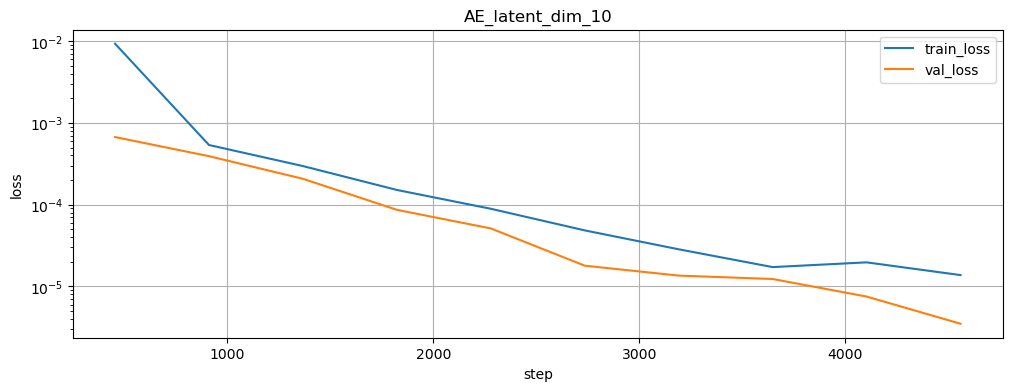

In [201]:
import os

base_path = f"C:\\Users\\Alex\\Documents\\GitHub\\lightning_logs\\{exp_name}"
last_version = sorted(os.listdir(base_path))[-1]
log_path = f"{base_path}/{last_version}"

tbparse_visual(log_path, title=exp_name)

# or simply uncomment these two lines
# %load_ext tensorboard
# %tensorboard --logdir lightning_logs/AE_latent_dim=2 --port 6006

In [179]:
trainer.test(autoencoder, test_loader)
run_res = autoencoder.test_result

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

In [180]:
ID = 1
print(run_res['real'][ID, :])
print(run_res['recon'][ID, :])
print(run_res['latent'][ID, :])

[2. 2. 6. 2. 6. 8. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.01227999 0.         0.         0.
 0.         0.         0.31964704 0.         0.         0.
 0.         0.16231804 0.41444117 0.         0.32260576 0.
 0.20237626 0.         0.         0.         0.37310654 0.        ]
[-0.12853129  0.04872374 -0.27641404  0.04952743  0.16988698 -0.46622688
 -0.09986702 -0.36385682  0.29472968  0.40954334]


## Optuning

In [203]:
batch_size = 128
e_train = torch.tensor(e_train.values, dtype=torch.float32)
train_set = TensorDataset(e_train, e_train)
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True
)


e_val = torch.tensor(e_test.values, dtype=torch.float32)
val_set = TensorDataset(e_val, e_val)
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True
)

e_test = torch.tensor(e_test.values, dtype=torch.float32)
test_set = TensorDataset(e_test, e_test)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True
)

In [204]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dims):
        super().__init__()

        modules = []
        in_features = input_dim
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Linear(in_features, h_dim),
                    nn.BatchNorm1d(h_dim),
                    nn.LeakyReLU(),
                )
            )
            in_features = h_dim

        modules.append(nn.Linear(in_features, latent_dim))
        self.encoder = nn.Sequential(*modules)

    def forward(self, x):
        return self.encoder(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, hidden_dims):
        super().__init__()

        modules = []
        in_features = latent_dim
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Linear(in_features, h_dim),
                    nn.BatchNorm1d(h_dim),
                    nn.LeakyReLU(),
                )
            )
            in_features = h_dim

        modules.append(nn.Linear(in_features, output_dim))
        self.decoder = nn.Sequential(*modules)

    def forward(self, x):
        return self.decoder(x)


In [205]:
# !pip install -q lightning tbparse
import lightning as L
import torch.nn.functional as F
from collections import defaultdict


class LitAE(L.LightningModule):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def configure_optimizers(self):
        lr = getattr(self, "learning_rate", 1e-4)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=8, factor=0.5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }



    def forward_handler(self, data, *args, **kwargs):
        # here is the logic how data is moved through AE
        latent = self.encoder(data)
        recon = self.decoder(latent)
        return latent, recon

    def loss_handler(self, recon, data, *args, **kwargs):
        # here is the loss function computing
        loss = F.mse_loss(recon, data).mean()
        return loss

    def training_step(self, batch, batch_idx):
        data, labels = batch

        latent, recon = self.forward_handler(data, labels)
        loss = self.loss_handler(recon, data, latent)

        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        data, labels = batch

        latent, recon = self.forward_handler(data, labels)
        loss = self.loss_handler(recon, data, latent)

        self.log("val_loss", loss, on_step=False, on_epoch=True)
        return loss

    def on_test_epoch_start(self):
        # create dict with empty tensors for further accumulating over batches
        self.test_result = defaultdict(torch.Tensor)

    def test_step(self, batch, batch_idx):
        data, labels = batch

        latent, recon = self.forward_handler(data, labels)
        self.update_test_result(data, recon, latent, labels)

    def update_test_result(self, data, recon, latent, labels):
        # accumulating results every batch
        self.test_result["real"] = torch.cat([self.test_result["real"], data.cpu()])
        self.test_result["recon"] = torch.cat([self.test_result["recon"], recon.cpu()])
        self.test_result["latent"] = torch.cat(
            [self.test_result["latent"], latent.cpu()]
        )
        self.test_result["labels"] = torch.cat(
            [self.test_result["labels"], labels.cpu()]
        )

    def on_test_epoch_end(self):
        # simply change type from torch tensor to numpy array
        # for every item in test_result dictionary
        for key in self.test_result:
            self.test_result[key] = self.test_result[key].numpy()

In [206]:
import optuna
import lightning as L
import torch

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

def objective(trial):
    
    # create trial-specific directory to avoid file overwrites
    ckpt_dir = f"C:\\Users\\Alex\\Documents\\GitHub\\optuna_ckpts\\trial_{trial.number}"
    os.makedirs(ckpt_dir, exist_ok=True)

    checkpoint_callback = ModelCheckpoint(
        dirpath=ckpt_dir,
        filename="best",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    # ---- Hyperparameter search space ----
    n_layers = trial.suggest_int("n_layers", 3, 6)

    hidden_dims = [
        trial.suggest_int(f"h_dim_{i}", 4, 64)
        for i in range(n_layers)
    ]

    latent_dim = trial.suggest_int("latent_dim", 2, 16)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    # ---- Build model ----
    encoder = Encoder(input_dim=30, latent_dim=latent_dim, hidden_dims=hidden_dims)
    decoder = Decoder(latent_dim=latent_dim, output_dim=30, hidden_dims=list(reversed(hidden_dims)))

    model = LitAE(encoder, decoder)

    # Modify learning rate inside LightningModule
    model.learning_rate = lr

    # ---- Trainer ----
    trainer = L.Trainer(
        max_epochs=500,
        enable_checkpointing=True,
        callbacks=[checkpoint_callback,
                   EarlyStopping(monitor="val_loss", mode="min", patience = 20)],
        logger=False,
        accelerator="gpu",  # change to "gpu" if needed
    )

    trainer.fit(model, train_loader, val_loader)

    # Return best validation loss
    return trainer.callback_metrics["val_loss"].item()


In [207]:
study = optuna.create_study(direction="minimize",
                           sampler=optuna.samplers.TPESampler(multivariate=True, group=True))
study.optimize(objective, n_trials=100, show_progress_bar = True, n_jobs = 1)

best_trial = study.best_trial
print("Best params:", best_trial.params)
print("Best trial number:", best_trial.number)


C:\Users\Alex\AppData\Roaming\Python\Python311\site-packages\optuna\samplers\_tpe\sampler.py:319: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Users\Alex\AppData\Roaming\Python\Python311\site-packages\optuna\samplers\_tpe\sampler.py:330: ExperimentalWarning: ``group`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-02-20 16:52:45,685] A new study created in memory with name: no-name-2f57b12a-93b2-4503-80b5-54eebc2794fe


  0%|          | 0/100 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
C:\ProgramData\anaconda3\envs\TorchCUDA\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:751: Checkpoint directory C:\Users\Alex\Documents\GitHub\optuna_ckpts\trial_0 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | encoder | Encoder | 5.6 K  | train
1 | decoder | Decoder | 5.6 K  | train
--------------------------------------------
11.3 K    Trainable params
0         Non-trainable params
11.3 K    Total params
0.045     Total estimated model params size (MB)
38        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

[I 2026-02-21 02:26:06,422] Trial 99 finished with value: 0.014610419049859047 and parameters: {'n_layers': 4, 'h_dim_0': 18, 'h_dim_1': 56, 'h_dim_2': 7, 'h_dim_3': 6, 'latent_dim': 9, 'lr': 0.00012178609354511689}. Best is trial 59 with value: 0.0010909754782915115.
Best params: {'n_layers': 3, 'h_dim_0': 64, 'h_dim_1': 57, 'h_dim_2': 61, 'latent_dim': 14, 'lr': 0.000976010784143978}
Best trial number: 59


In [28]:
best_trial = study.best_trial
print("Best params:", best_trial.params)
print("Best trial number:", best_trial.number)

Best params: {'n_layers': 3, 'h_dim_0': 55, 'h_dim_1': 55, 'h_dim_2': 53, 'latent_dim': 16, 'lr': 0.0007730410148782536}
Best trial number: 422


In [31]:
# with open(f'C:\\Users\\Alex\\Documents\\GitHub\\Stark_ML\\autoencoder_optimal_parameters', 'w') as fp:
#     json.dump(study.best_params, fp)

In [209]:
# optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_optimization_history(study)
# optuna.visualization.plot_slice(study)

In [213]:
#Autoencoder trained on StarkML training set configurations
hidden_dims=[55, 55, 53]
best_encoder = Encoder(input_dim=30, latent_dim=16, hidden_dims=hidden_dims)
best_decoder = Decoder(latent_dim=16, output_dim=30, hidden_dims=list(reversed(hidden_dims)))

best_model = LitAE.load_from_checkpoint("C:\\Users\\Alex\\Documents\\GitHub\\optuna_ckpts\\trial_422\\best.ckpt",
                                       encoder = best_encoder,
                                       decoder = best_decoder)
best_model

LitAE(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Sequential(
        (0): Linear(in_features=30, out_features=55, bias=True)
        (1): BatchNorm1d(55, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (1): Sequential(
        (0): Linear(in_features=55, out_features=55, bias=True)
        (1): BatchNorm1d(55, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (2): Sequential(
        (0): Linear(in_features=55, out_features=53, bias=True)
        (1): BatchNorm1d(53, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (3): Linear(in_features=53, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Sequential(
        (0): Linear(in_features=16, out_features=53, bias=True)
        (1): BatchNorm1d(53, eps=1e-05, 

In [220]:
#Autoencoder trained on all DB configurations
hidden_dims=[64, 57, 61]
best_encoder = Encoder(input_dim=30, latent_dim=14, hidden_dims=hidden_dims)
best_decoder = Decoder(latent_dim=14, output_dim=30, hidden_dims=list(reversed(hidden_dims)))

best_model = LitAE.load_from_checkpoint("C:\\Users\\Alex\\Documents\\GitHub\\optuna_ckpts\\trial_59\\best-v1.ckpt",
                                       encoder = best_encoder,
                                       decoder = best_decoder)
best_model

LitAE(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Sequential(
        (0): Linear(in_features=30, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (1): Sequential(
        (0): Linear(in_features=64, out_features=57, bias=True)
        (1): BatchNorm1d(57, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (2): Sequential(
        (0): Linear(in_features=57, out_features=61, bias=True)
        (1): BatchNorm1d(61, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (3): Linear(in_features=61, out_features=14, bias=True)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Sequential(
        (0): Linear(in_features=14, out_features=61, bias=True)
        (1): BatchNorm1d(61, eps=1e-05, 

In [221]:
def encode_features(X, encoder):
    """
    
    """
    encoder.eval()
    encoder.cpu()
    torch.set_grad_enabled(False)   
    
    #Select features that need encoding and concatenate them for lower and upper state vertically
    for_enc = concatenate_lower_upper_configurations(X)
    for_enc = torch.tensor(for_enc.values, dtype=torch.float32)
    
    
    with torch.no_grad():
        encoded = encoder(for_enc)
    encoded = encoded.cpu().numpy()
    
    enc_concat = pd.concat([
            X[['Charge']],
            pd.DataFrame(encoded[:int(encoded.shape[0]/2), :],
                         index = X.index,
                         columns = [f'lat_{i}' for i in range(encoded.shape[1])]),
            X[['Multiplicity', 'Term', 'Parity', 'J', 'E lower']],
            pd.DataFrame(encoded[int(encoded.shape[0]/2):, :],
                         index = X.index,
                         columns = [f'lat_{i}.1' for i in range(encoded.shape[1])]),
            X[['Multiplicity.1', 'Term.1', 'Parity.1', 'J.1', 'E upper']],
            X[['Gap to ion', 'T']],    
        ],
                axis = 1)
    
    return enc_concat

In [247]:
encoder = best_model.encoder

aaaa_train = encode_features(X_train, encoder)
aaaa_test  = encode_features(X_test, encoder)
aaaa_elem  = encode_features(X_elem, encoder)

In [248]:
print(aaaa_train.head())
aaaa_train.describe()

      Charge     lat_0     lat_1     lat_2     lat_3     lat_4     lat_5  \
156        0 -3.434915 -1.391115  1.344142 -1.496149  1.138558  1.188936   
360        0 -3.385415 -1.839951  1.216622 -1.148182  1.533779  0.667870   
2041       4 -3.743973  0.014416  1.426925 -0.588900  0.141188  0.853640   
2264       5 -3.743973  0.014416  1.426925 -0.588900  0.141188  0.853640   
4587       1 -2.477809 -0.276929  2.024587 -0.720085  0.316682  0.406300   

         lat_6     lat_7     lat_8  ...  lat_11.1  lat_12.1  lat_13.1  \
156   0.811239  1.056068 -0.341512  ... -0.239322  0.036168 -0.688663   
360   0.767942  1.116128  0.127368  ... -0.281612  0.247722 -0.596867   
2041  0.952268  0.684600  0.297383  ... -0.607803 -0.320252 -0.821291   
2264  0.952268  0.684600  0.297383  ... -0.607803 -0.320252 -0.821291   
4587  0.592867  0.534626  0.315143  ...  0.193443  1.035041 -1.365419   

      Multiplicity.1  Term.1  Parity.1  J.1        E upper     Gap to ion  \
156                3       

,Charge,lat_0,lat_1,lat_2,lat_3,lat_4,lat_5,lat_6,lat_7,lat_8,...,lat_11.1,lat_12.1,lat_13.1,Multiplicity.1,Term.1,Parity.1,J.1,E upper,Gap to ion,T
count,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,...,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4875.000000,4.875000e+03,4875.000000,4875.000000
mean,1.094154,-1.861972,-0.510636,0.876176,-0.559318,0.399551,0.686326,0.971472,0.923252,-0.445927,...,-0.379663,0.420951,-0.513525,2.923282,1.763282,0.428718,2.007487,1.632695e+05,62974.466841,24769.313436
std,0.836167,1.683526,1.002290,1.177034,0.706180,0.910307,0.828472,1.011298,0.979149,1.242576,...,0.703904,0.557277,0.689303,1.137032,1.107740,0.494944,1.220127,1.076853e+05,59795.041797,23371.227617
min,0.000000,-4.640561,-2.424844,-2.975082,-1.951113,-2.174244,-1.447701,-0.547760,-1.352996,-3.807028,...,-2.830332,-1.135714,-1.999569,1.000000,0.000000,0.000000,0.000000,1.173231e+04,-24436.160000,1303.000000
25%,1.000000,-3.181015,-1.302071,-0.330582,-1.010933,-0.188800,0.406300,0.389378,0.534626,-0.534629,...,-0.898500,0.057500,-1.018829,2.000000,1.000000,0.000000,1.000000,8.134405e+04,27458.960000,12950.000000
50%,1.000000,-2.676871,-0.698989,1.233869,-0.694905,0.522454,0.786911,0.704912,0.878998,0.013856,...,-0.448989,0.419376,-0.663355,3.000000,2.000000,0.000000,2.000000,1.593934e+05,53861.930000,18800.000000
75%,1.000000,-0.149321,-0.179678,1.657143,-0.429152,0.839515,1.146829,1.133539,1.116128,0.315143,...,0.357801,0.711803,-0.177301,4.000000,2.000000,1.000000,2.500000,2.010724e+05,76540.238000,29000.000000
max,7.000000,1.639183,2.669864,2.363394,2.030758,2.727185,3.957065,4.442742,4.444198,1.123451,...,1.390188,2.587565,2.090006,7.000000,7.000000,1.000000,7.500000,1.135328e+06,793119.300000,493200.000000


### Ensemble 1

In [227]:
#XGBoost_A+I_Eraw_Raw_No
XGB_params = {
    'n_estimators' : 812,
    'learning_rate' : 0.05942837228764905,
    'max_depth' : 8,
    'min_child_weight' : 3,
    'reg_alpha' : 1.7317122692710318e-05,
    'reg_lambda' : 3.4689939467614055,
    }

model = xgboost.XGBRegressor(**XGB_params)

preds_1, preds_elem_1, fig, ax = plot_model_prediction({'AE':model},
                                                    aaaa_train, Y_train,
                                                    aaaa_test, unscale(Y_test),
                                                    aaaa_elem, unscale(Y_elem), L_elem,
                                                  plot = False)

In [233]:
#XGBoost_A+I_Enorm_Aug_No
XGB_params = {
    'n_estimators' : 915,
    'learning_rate' : 0.2374731153493416,
    'max_depth' : 6,
    'min_child_weight' : 7,
    'reg_alpha' : 0.012033189196720752,
    'reg_lambda' : 1.785764867044341e-05,
    }

model = xgboost.XGBRegressor(**XGB_params)

preds_2, preds_elem_2, fig, ax = plot_model_prediction({'AE':model},
                                                    aaaa_train, Y_train,
                                                    aaaa_test, unscale(Y_test),
                                                    aaaa_elem, unscale(Y_elem), L_elem,
                                                  plot = False)

In [238]:
#CatBoost_A+I_Enorm_Raw_No
CatBoost_params = {
    'learning_rate' : 0.15069764165168942,
    'max_depth' : 8,
    'l2_leaf_reg' : 1.761026153327166,
    'min_data_in_leaf' : 11,
    'random_strength' : 1.6296364541293666,
    }

model = cat.CatBoostRegressor(**CatBoost_params)

preds_3, preds_elem_3, fig, ax = plot_model_prediction({'AE':model},
                                                    aaaa_train, Y_train,
                                                    aaaa_test, unscale(Y_test),
                                                    aaaa_elem, unscale(Y_elem), L_elem,
                                                  plot = False)

0:	learn: 1.2745018	total: 7.37ms	remaining: 7.36s
1:	learn: 1.1705879	total: 14.1ms	remaining: 7.04s
2:	learn: 1.0849866	total: 21.6ms	remaining: 7.18s
3:	learn: 0.9984108	total: 28.6ms	remaining: 7.13s
4:	learn: 0.9305310	total: 34.7ms	remaining: 6.9s
5:	learn: 0.8709314	total: 40.7ms	remaining: 6.74s
6:	learn: 0.8080397	total: 46.9ms	remaining: 6.66s
7:	learn: 0.7679018	total: 52.9ms	remaining: 6.57s
8:	learn: 0.7302227	total: 58.9ms	remaining: 6.49s
9:	learn: 0.6962730	total: 64.8ms	remaining: 6.41s
10:	learn: 0.6701138	total: 70.8ms	remaining: 6.37s
11:	learn: 0.6397694	total: 76.7ms	remaining: 6.32s
12:	learn: 0.6113444	total: 82.6ms	remaining: 6.27s
13:	learn: 0.5941928	total: 88.4ms	remaining: 6.22s
14:	learn: 0.5741598	total: 94.4ms	remaining: 6.2s
15:	learn: 0.5613157	total: 101ms	remaining: 6.18s
16:	learn: 0.5496369	total: 107ms	remaining: 6.2s
17:	learn: 0.5313210	total: 114ms	remaining: 6.21s
18:	learn: 0.5232030	total: 120ms	remaining: 6.22s
19:	learn: 0.5113524	total: 1

176:	learn: 0.2376211	total: 1.19s	remaining: 5.55s
177:	learn: 0.2369868	total: 1.2s	remaining: 5.55s
178:	learn: 0.2364355	total: 1.21s	remaining: 5.56s
179:	learn: 0.2358020	total: 1.22s	remaining: 5.56s
180:	learn: 0.2357776	total: 1.23s	remaining: 5.57s
181:	learn: 0.2348664	total: 1.24s	remaining: 5.57s
182:	learn: 0.2342348	total: 1.25s	remaining: 5.57s
183:	learn: 0.2335362	total: 1.25s	remaining: 5.57s
184:	learn: 0.2330169	total: 1.26s	remaining: 5.56s
185:	learn: 0.2326904	total: 1.27s	remaining: 5.57s
186:	learn: 0.2324281	total: 1.28s	remaining: 5.57s
187:	learn: 0.2318471	total: 1.29s	remaining: 5.56s
188:	learn: 0.2313856	total: 1.3s	remaining: 5.56s
189:	learn: 0.2300660	total: 1.3s	remaining: 5.56s
190:	learn: 0.2297136	total: 1.31s	remaining: 5.56s
191:	learn: 0.2293504	total: 1.32s	remaining: 5.56s
192:	learn: 0.2285631	total: 1.33s	remaining: 5.56s
193:	learn: 0.2281516	total: 1.34s	remaining: 5.55s
194:	learn: 0.2276372	total: 1.34s	remaining: 5.55s
195:	learn: 0.2

353:	learn: 0.1744512	total: 2.59s	remaining: 4.73s
354:	learn: 0.1742534	total: 2.6s	remaining: 4.72s
355:	learn: 0.1740417	total: 2.61s	remaining: 4.71s
356:	learn: 0.1738973	total: 2.61s	remaining: 4.71s
357:	learn: 0.1737324	total: 2.62s	remaining: 4.7s
358:	learn: 0.1737034	total: 2.63s	remaining: 4.69s
359:	learn: 0.1734598	total: 2.63s	remaining: 4.68s
360:	learn: 0.1731660	total: 2.64s	remaining: 4.67s
361:	learn: 0.1729255	total: 2.65s	remaining: 4.67s
362:	learn: 0.1728953	total: 2.65s	remaining: 4.66s
363:	learn: 0.1726546	total: 2.66s	remaining: 4.65s
364:	learn: 0.1723982	total: 2.67s	remaining: 4.64s
365:	learn: 0.1721335	total: 2.67s	remaining: 4.63s
366:	learn: 0.1720110	total: 2.68s	remaining: 4.63s
367:	learn: 0.1717634	total: 2.69s	remaining: 4.62s
368:	learn: 0.1714747	total: 2.7s	remaining: 4.61s
369:	learn: 0.1712610	total: 2.7s	remaining: 4.6s
370:	learn: 0.1709259	total: 2.71s	remaining: 4.59s
371:	learn: 0.1707567	total: 2.71s	remaining: 4.58s
372:	learn: 0.170

538:	learn: 0.1431249	total: 3.79s	remaining: 3.24s
539:	learn: 0.1429984	total: 3.79s	remaining: 3.23s
540:	learn: 0.1428989	total: 3.8s	remaining: 3.23s
541:	learn: 0.1427246	total: 3.81s	remaining: 3.22s
542:	learn: 0.1426446	total: 3.81s	remaining: 3.21s
543:	learn: 0.1424972	total: 3.82s	remaining: 3.2s
544:	learn: 0.1423770	total: 3.83s	remaining: 3.19s
545:	learn: 0.1421293	total: 3.83s	remaining: 3.19s
546:	learn: 0.1419826	total: 3.84s	remaining: 3.18s
547:	learn: 0.1418202	total: 3.84s	remaining: 3.17s
548:	learn: 0.1415636	total: 3.85s	remaining: 3.16s
549:	learn: 0.1414798	total: 3.86s	remaining: 3.15s
550:	learn: 0.1413201	total: 3.86s	remaining: 3.15s
551:	learn: 0.1412881	total: 3.87s	remaining: 3.14s
552:	learn: 0.1411848	total: 3.87s	remaining: 3.13s
553:	learn: 0.1411138	total: 3.88s	remaining: 3.12s
554:	learn: 0.1409358	total: 3.89s	remaining: 3.12s
555:	learn: 0.1408979	total: 3.89s	remaining: 3.11s
556:	learn: 0.1407637	total: 3.9s	remaining: 3.1s
557:	learn: 0.14

702:	learn: 0.1252293	total: 4.78s	remaining: 2.02s
703:	learn: 0.1251624	total: 4.79s	remaining: 2.01s
704:	learn: 0.1250050	total: 4.79s	remaining: 2.01s
705:	learn: 0.1249700	total: 4.8s	remaining: 2s
706:	learn: 0.1248971	total: 4.81s	remaining: 1.99s
707:	learn: 0.1247878	total: 4.81s	remaining: 1.99s
708:	learn: 0.1246867	total: 4.82s	remaining: 1.98s
709:	learn: 0.1246296	total: 4.83s	remaining: 1.97s
710:	learn: 0.1246019	total: 4.83s	remaining: 1.96s
711:	learn: 0.1245877	total: 4.84s	remaining: 1.96s
712:	learn: 0.1245716	total: 4.84s	remaining: 1.95s
713:	learn: 0.1245300	total: 4.85s	remaining: 1.94s
714:	learn: 0.1244680	total: 4.86s	remaining: 1.94s
715:	learn: 0.1244463	total: 4.86s	remaining: 1.93s
716:	learn: 0.1244086	total: 4.87s	remaining: 1.92s
717:	learn: 0.1243415	total: 4.87s	remaining: 1.91s
718:	learn: 0.1242792	total: 4.88s	remaining: 1.91s
719:	learn: 0.1242444	total: 4.88s	remaining: 1.9s
720:	learn: 0.1241561	total: 4.89s	remaining: 1.89s
721:	learn: 0.124

867:	learn: 0.1134647	total: 5.78s	remaining: 878ms
868:	learn: 0.1133754	total: 5.78s	remaining: 872ms
869:	learn: 0.1133262	total: 5.79s	remaining: 865ms
870:	learn: 0.1133121	total: 5.79s	remaining: 858ms
871:	learn: 0.1133115	total: 5.8s	remaining: 852ms
872:	learn: 0.1132271	total: 5.81s	remaining: 845ms
873:	learn: 0.1131917	total: 5.81s	remaining: 838ms
874:	learn: 0.1131734	total: 5.82s	remaining: 831ms
875:	learn: 0.1131246	total: 5.83s	remaining: 825ms
876:	learn: 0.1130451	total: 5.83s	remaining: 818ms
877:	learn: 0.1129743	total: 5.84s	remaining: 811ms
878:	learn: 0.1127469	total: 5.84s	remaining: 804ms
879:	learn: 0.1127177	total: 5.85s	remaining: 798ms
880:	learn: 0.1126939	total: 5.86s	remaining: 791ms
881:	learn: 0.1126583	total: 5.86s	remaining: 784ms
882:	learn: 0.1126279	total: 5.87s	remaining: 777ms
883:	learn: 0.1125829	total: 5.87s	remaining: 771ms
884:	learn: 0.1124557	total: 5.88s	remaining: 764ms
885:	learn: 0.1124036	total: 5.88s	remaining: 757ms
886:	learn: 0

In [243]:
#LightGBM_A+I_Enorm_Raw_Scaler
LightGBM_params = {
    'n_estimators' : 851,
    'learning_rate' : 0.0828676033297886,
    'num_leaves' : 36,
    'reg_alpha' : 1.3694954099964075e-07,
    'reg_lambda' : 3.380662096472024e-05,
    }

scaler = StandardScaler()
scaler.fit(aaaa_train)

model = lightgbm.LGBMRegressor(**LightGBM_params)

preds_4, preds_elem_4, fig, ax = plot_model_prediction({'AE':model},
                                                        scaler.transform(aaaa_train), Y_train,
                                                        scaler.transform(aaaa_test), unscale(Y_test),
                                                        scaler.transform(aaaa_elem), unscale(Y_elem), L_elem,
                                                  plot = False)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6040
[LightGBM] [Info] Number of data points in the train set: 4875, number of used features: 41
[LightGBM] [Info] Start training from score 5.961954


In [249]:
#LightGBM_A+I_Eraw_Raw_No
LightGBM_params = {
    'n_estimators' : 678,
    'learning_rate' : 0.06783690493335369,
    'num_leaves' : 56,
    'reg_alpha' : 0.2466322868565492,
    'reg_lambda' : 0.2347079473461838,
    }

model = lightgbm.LGBMRegressor(**LightGBM_params)

preds_5, preds_elem_5, fig, ax = plot_model_prediction({'AE':model},
                                                        aaaa_train, Y_train,
                                                        aaaa_test, unscale(Y_test),
                                                        aaaa_elem, unscale(Y_elem), L_elem,
                                                  plot = False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5954
[LightGBM] [Info] Number of data points in the train set: 4875, number of used features: 41
[LightGBM] [Info] Start training from score 5.961954


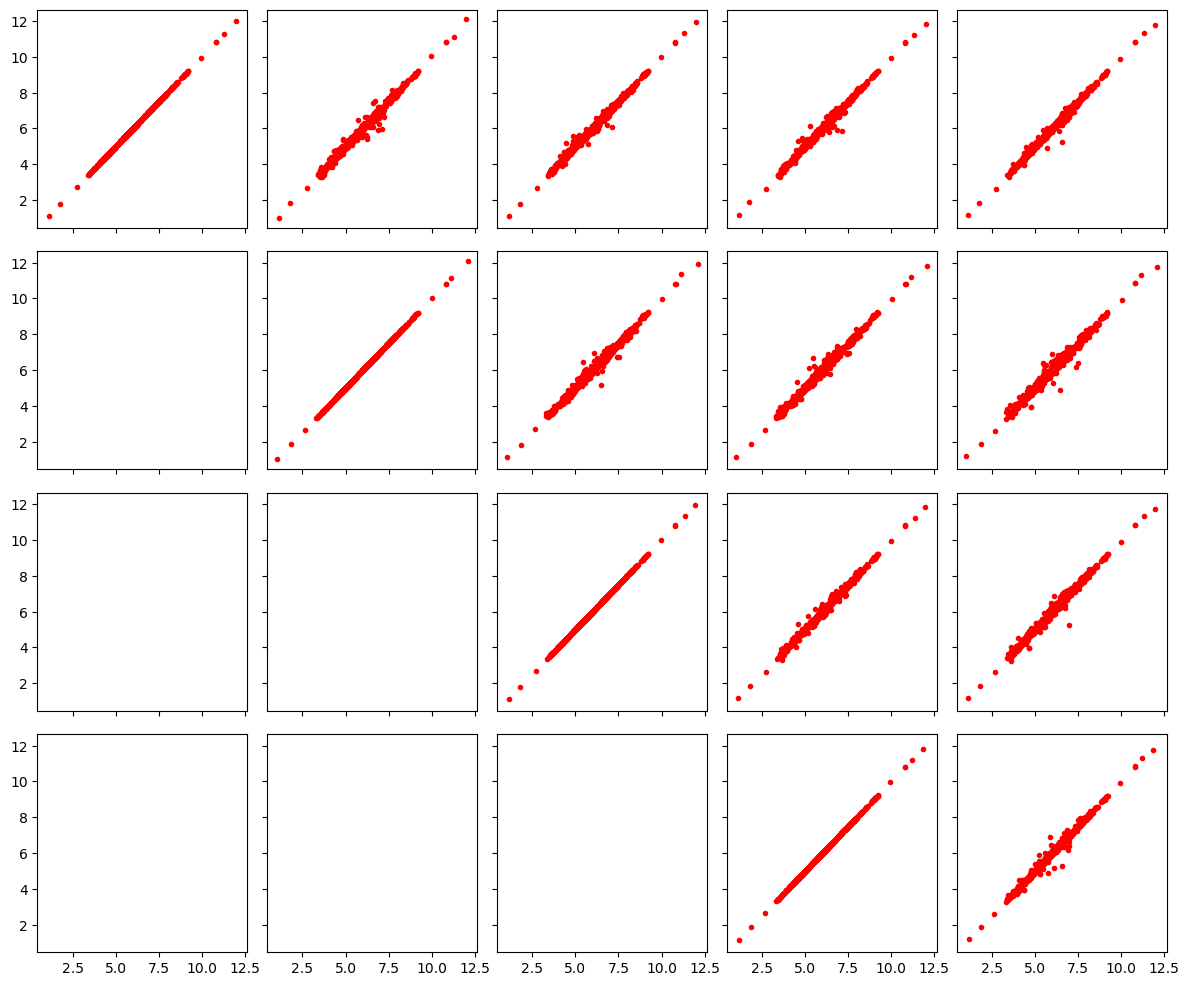

In [250]:
fig, ax = plt.subplots(4, 5, figsize = (12, 10), sharex=True, sharey=True)
ax[0, 0].plot(preds_1['AE'], preds_1['AE'], 'r.')
ax[0, 1].plot(preds_1['AE'], preds_2['AE'], 'r.')
ax[0, 2].plot(preds_1['AE'], preds_3['AE'], 'r.')
ax[0, 3].plot(preds_1['AE'], preds_4['AE'], 'r.')
ax[0, 4].plot(preds_1['AE'], preds_5['AE'], 'r.')

ax[1, 1].plot(preds_2['AE'], preds_2['AE'], 'r.')
ax[1, 2].plot(preds_2['AE'], preds_3['AE'], 'r.')
ax[1, 3].plot(preds_2['AE'], preds_4['AE'], 'r.')
ax[1, 4].plot(preds_2['AE'], preds_5['AE'], 'r.')

ax[2, 2].plot(preds_3['AE'], preds_3['AE'], 'r.')
ax[2, 3].plot(preds_3['AE'], preds_4['AE'], 'r.')
ax[2, 4].plot(preds_3['AE'], preds_5['AE'], 'r.')

ax[3, 3].plot(preds_4['AE'], preds_4['AE'], 'r.')
ax[3, 4].plot(preds_4['AE'], preds_5['AE'], 'r.')

plt.tight_layout()
plt.show()

0.26855380864874406
18.048587488383163


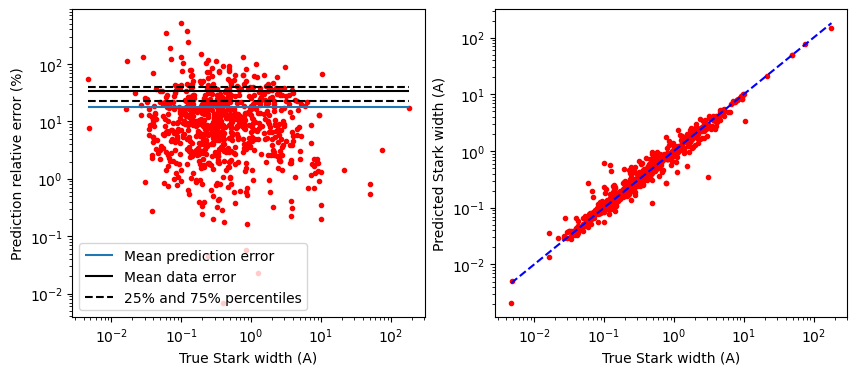

In [251]:
preds_ensemble      = (preds_1['AE'] + preds_2['AE'] + preds_3['AE'] + preds_4['AE'] + preds_5['AE'])/5
preds_elem_ensemble = (preds_elem_1['AE'] + preds_elem_2['AE'] + preds_elem_3['AE'] + preds_elem_4['AE'] + preds_elem_5['AE'])/5

print(root_mean_squared_error(Y_test, preds_ensemble))
MREs = (np.abs(unscale(Y_test) - unscale(preds_ensemble.reshape(preds_ensemble.shape[0]))) / unscale(Y_test))*100
print(MREs.mean())

fig, ax = plt.subplots(1, 2, figsize = (10, 4))
ax[0].plot(unscale(Y_test), MREs, 'r.')
ax[0].hlines(MREs.mean(), np.amin(unscale(Y_test)), np.amax(unscale(Y_test)), label = 'Mean prediction error')
ax[0].hlines(34.438211, np.amin(unscale(Y_test)), np.amax(unscale(Y_test)), ls = '-', color = 'k', label = 'Mean data error')
ax[0].hlines(23., np.amin(unscale(Y_test)), np.amax(unscale(Y_test)), ls = '--', color = 'k', label = '25% and 75% percentiles')
ax[0].hlines(40., np.amin(unscale(Y_test)), np.amax(unscale(Y_test)), ls = '--', color = 'k')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].legend()
ax[0].set_xlabel('True Stark width (A)')
ax[0].set_ylabel('Prediction relative error (%)')

ax[1].plot(unscale(Y_test), unscale(preds_ensemble), 'r.')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].plot([np.amin(unscale(Y_test)), np.amax(unscale(Y_test))],
           [np.amin(unscale(Y_test)), np.amax(unscale(Y_test))], color = 'b', ls = '--')
ax[1].set_xlabel('True Stark width (A)')
ax[1].set_ylabel('Predicted Stark width (A)')
# plt.savefig(f'Ensemble_1 Test predictions.svg', transparent = True, format = 'svg')
plt.show()

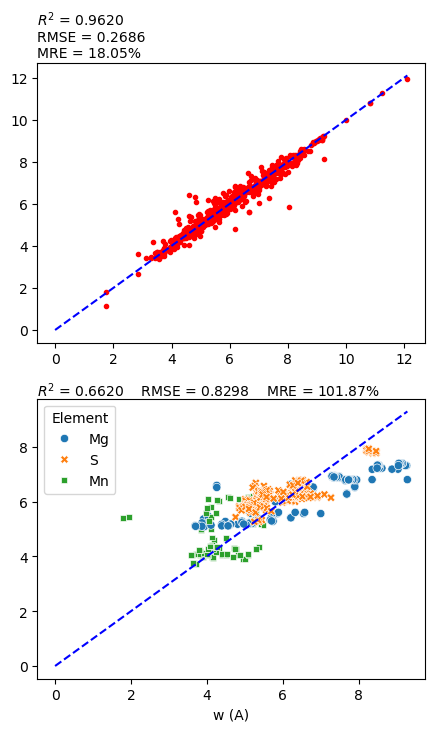

In [252]:
R2 = {}
RMSE = {}
R2 = r2_score(Y_test, preds_ensemble)
RMSE = root_mean_squared_error(Y_test, preds_ensemble)
MRE = ((np.abs(unscale(Y_test) - unscale(preds_ensemble)) / unscale(Y_test))*100).mean()

R2_elem = {}
RMSE_elem = {}
R2_elem = r2_score(Y_elem, preds_elem_ensemble)
RMSE_elem = root_mean_squared_error(Y_elem, preds_elem_ensemble)
MRE_elem = ((np.abs(unscale(Y_elem) - unscale(preds_elem_ensemble)) / unscale(Y_elem))*100).mean()

fig, ax = plt.subplots(2, 1, figsize = (5*1, 4*2))
ax[0].plot(Y_test, preds_ensemble, 'r.')
ax[0].plot([0, np.amax(Y_test)], [0, np.amax(Y_test)], color = 'b', ls = '--')
# ax[0].set_title(f'{name}')
ax[0].text(x = 0, y = 1.02, s = f'$R^2$ = {R2:.4f}  \nRMSE = {RMSE:.4f} \nMRE = {MRE:.2f}%', 
           transform = ax[0].transAxes)


sns.scatterplot(x = Y_elem, y = preds_elem_ensemble, ax = ax[1], style = L_elem['Element'], hue = L_elem['Element'])
ax[1].plot([0, np.amax(Y_elem)], [0, np.amax(Y_elem)], color = 'b', ls = '--')
ax[1].text(x = 0, y = 1.01, s = f'$R^2$ = {R2_elem:.4f}    RMSE = {RMSE_elem:.4f}    MRE = {MRE_elem:.2f}%',
           transform = ax[1].transAxes)

plt.show()

# Temperature dependence

In [36]:
data_width['Wavelength'].value_counts()

Wavelength
538.337    38
480.602    28
667.815    27
501.568    24
385.602    23
           ..
281.781     1
283.964     1
293.598     1
294.529     1
470.530     1
Name: count, Length: 2666, dtype: int64

He 667.815 nm; 27 data points;   27 points in train
Data from 16900.0K to 42050.0 available for this line


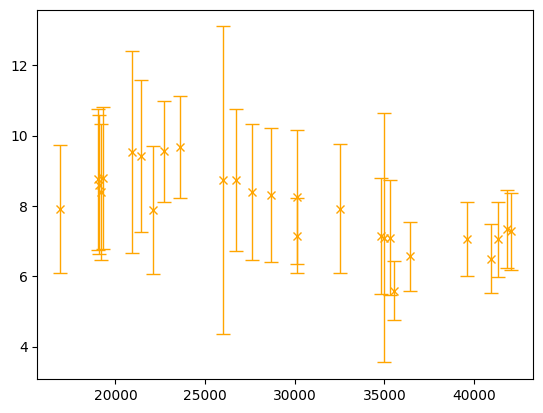

	Points plotted are only original data (without artificial points)


In [50]:
#Select one of the lines with the highest number of entries in full dataset
#Set index "idx"from 0 to ..., where 0 represents the line with the highest number of entries
idx = 2
wavelength = list(data_width['Wavelength'].value_counts().index)[idx]
data_width_train_full, target_width_train_full = data_width_train.copy(), target_width_train.copy()
data_width_elements_full, target_width_elements_full = data_width_elements.copy(), target_width_elements.copy()
data_width_train, target_width_train = data_width.copy(), target_width.copy()

line_data = data.loc[(data_width['Wavelength'] == wavelength) & (data['w (A)'].isna() == False)]
line_data_train = data_width_train[data_width_train['Wavelength'] == wavelength]

# data_width_train, target_width_train = data_width_train.drop(line_data_train.index), target_width_train.drop(line_data_train.index)
data_width_elements   = line_data.drop(columns = ['w (A)', 'd (A)','w error (%)', 'd error (%)'])
target_width_elements = line_data['w (A)']
label_width_elements = line_data['Element']

print(line_data['Element'].iloc[0], line_data['Wavelength'].iloc[0], 'nm;', line_data.shape[0], 'data points;', ' ',
     data_width_train[data_width_train['Wavelength'] == wavelength].shape[0], 'points in train')

T_low, T_high = line_data['T'].describe()['min'], line_data['T'].describe()['max']
print(f'Data from {T_low}K to {T_high} available for this line')

fig, ax = plt.subplots()
ax.plot(line_data['T'], line_data['w (A)'], color = 'orange', ls = 'None', marker = 'x')
ax.errorbar(line_data.loc[line_data['w error (%)'].isna() == False]['T'],
           line_data.loc[line_data['w error (%)'].isna() == False]['w (A)'],
           yerr = line_data.loc[line_data['w error (%)'].isna() == False]['w error (%)']/100*line_data.loc[line_data['w error (%)'].isna() == False]['w (A)'],
           color = 'orange', ls = 'None', capsize=5, lw = 1)

plt.show()

print(f'\tPoints plotted are only original data (without artificial points)')

In [51]:
#Define temperature range in each case
T_low, T_high = line_data['T'].describe()['min'], line_data['T'].describe()['max']

npoints = int((T_high - T_low)//500)
temperatures = np.linspace(T_low, T_high, npoints)

unit = line_data[line_data['Wavelength'].duplicated() == False]

for i in range(npoints):
    unit['T'] = temperatures[i]
    if i == 0:
        temperature_test_data = unit.copy()
    else:
        temperature_test_data = pd.concat([temperature_test_data, unit])

temperature_test_data = temperature_test_data.drop(columns=['w (A)', 'd (A)',
                                                            'w error (%)', 'd error (%)'])

C:\Users\Alex\AppData\Local\Temp\1\ipykernel_17800\2323132408.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unit['T'] = temperatures[i]


In [52]:
data_width_test_full, target_width_test_full = data_width_test.copy(), target_width_test.copy()
data_width_test, target_width_test = temperature_test_data.reset_index(drop = True), temperature_test_data['1s'].reset_index(drop = True)

In [53]:
models = [
    # ['XGB_A+I_Eraw_Raw_No', 'CatBoost_A+I_Enorm_Raw_No', 'LightGBM_A+I_Enorm_Raw_Scaler', 'LightGBM_A+I_Eraw_Raw_No', 'XGB_A+I_Enorm_Aug_No'],
#     ['XGB_A+I_Eraw_Raw_No', 'CatBoost_A+I_Enorm_Raw_No', 'LightGBM_A+I_Enorm_Raw_Scaler', 'LightGBM_A+I_Eraw_Raw_No', 'XGB_A+I_Enorm_Aug_No', 'CatBoost_A+I_Eraw_Raw_No'],
#     ['XGB_A+I_Eraw_Raw_No', 'CatBoost_A+I_Enorm_Raw_No'],
    # ['LightGBM_A+I_Eraw_Raw_Scaler'],
    # ['XGB_A+I_Eraw_Raw_No'],
        ['KNN_A+I_Enorm_Raw_Scaler']]
glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'

models_d     = {}
preds_d      = []
preds_elem_d = []

for ensemble in tqdm(models):
    preds_ensemble      = {}
    preds_elem_ensemble = {}
    for item in ensemble:
        if '_A+I_' in item:
            parameter = 'width'
        elif '_Shift_' in item:
            parameter = 'shift'
        else:
            raise NameError(f"Parameter for prediction must be specified in model's name: {item}")

        if 'KNN' in item:
            path = glob_path + '\\KNN'
        elif 'RF' in item:
            path = glob_path + '\\RF'
        elif 'XGB' in item:
            path = glob_path + '\\XGB'
        elif 'LightGBM' in item:
            path = glob_path + '\\LightGBM'
        elif 'CatBoost' in item:
            path = glob_path + '\\CatBoost'

        models_d_item = create_models_dict([item], path = path)

        if '_Eraw_' in item:
            normalized_energy = False
        elif '_Enorm' in item:
            normalized_energy = True

        if '_Raw_' in item:
            augmented_train_set = False
        elif '_Aug_' in item:
            augmented_train_set = True

        if '_No' in item:
            apply_scaler = False
        elif '_Scaler' in item:
            apply_scaler = True

        X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter,
                                                                                             augmented_train_set,
                                                                                             scaled_target=True,
                                                                                             normalized_energy = normalized_energy,
                                                                                             print_stats = False)
        if apply_scaler:
            preds, preds_elem = plot_model_prediction(models_d_item,
                                                      scaler.transform(X_train), Y_train,
                                                      scaler.transform(X_test), Y_test,
                                                      scaler.transform(X_elem), Y_elem, L_elem, 
                                                      plot = False)
        else:
            preds, preds_elem = plot_model_prediction(models_d_item,
                                                      X_train, Y_train,
                                                      X_test, Y_test,
                                                      X_elem, Y_elem, L_elem, 
                                                      plot = False)
        preds_ensemble = preds_ensemble | preds
        preds_elem_ensemble = preds_elem_ensemble | preds_elem
    
    pred = np.zeros(preds_ensemble[ensemble[0]].shape)
    pred_elem = np.zeros(preds_elem_ensemble[ensemble[0]].shape)
    for key in preds_ensemble.keys():
        pred += preds_ensemble[key]
        pred_elem += preds_elem_ensemble[key]
    pred /= len(preds_ensemble.keys())
    pred_elem /= len(preds_elem_ensemble.keys())
    
    preds_d.append(pred)
    preds_elem_d.append(pred_elem)

data_width_train, target_width_train = data_width_train_full.copy(), target_width_train_full.copy()
data_width_test, target_width_test   = data_width_test_full.copy(), target_width_test_full.copy()
data_width_elements, target_width_elements = data_width_elements_full.copy(), target_width_elements_full.copy()

  0%|          | 0/1 [00:00<?, ?it/s]

In [54]:
RMSE_Temperature = []
for i in preds_elem_d:
    RMSE_Temperature.append(root_mean_squared_error(unscale(i), unscale(Y_elem)))

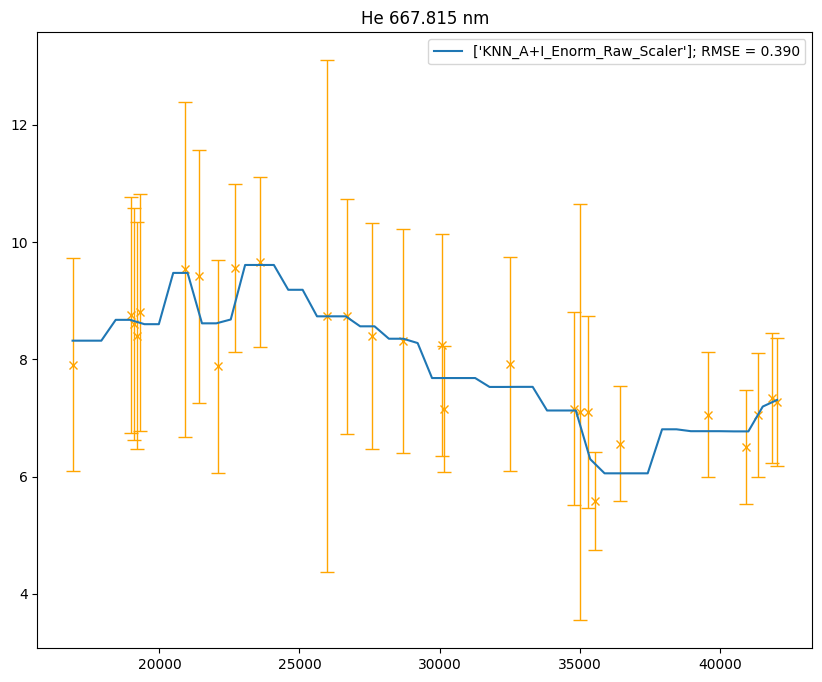

In [55]:
fig, ax = plt.subplots(figsize = (10, 8))
ax.plot(line_data['T'], line_data['w (A)'], color = 'orange', ls = 'None', marker = 'x')
ax.errorbar(line_data.loc[line_data['w error (%)'].isna() == False]['T'],
           line_data.loc[line_data['w error (%)'].isna() == False]['w (A)'],
           yerr = line_data.loc[line_data['w error (%)'].isna() == False]['w error (%)']/100*line_data.loc[line_data['w error (%)'].isna() == False]['w (A)'],
           color = 'orange', ls = 'None', capsize=5, lw = 1)
for i in range(len(models)):
    ax.plot(temperatures, unscale(preds_d[i]), label = str(models[i]) + '; RMSE = ' + str(f'{RMSE_Temperature[i]:.3f}'))

ax.legend()
ax.set_title(f"{line_data['Element'].iloc[0]} {line_data['Wavelength'].iloc[0]} nm")
# ax.set_ylim(-0.02, 0.5)
# plt.savefig('Temperature dependence He.svg', transparent = True)
plt.show()

# Saving models trained on full data

## Width ensmble models

### XGB_A+I_Eraw_Raw_No

In [120]:
data_width_train_full, target_width_train_full = data_width_train.copy(), target_width_train.copy()

data_width_train, target_width_train = pd.concat([data_width, data_width_elements]), pd.concat([target_width, target_width_elements])

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'XGB_A+I_Eraw_Raw_No',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'width',
                                                                                     augmented_train_set = False,
                                                                                     scaled_target = True,
                                                                                     normalized_energy = False,
                                                                                     print_stats = True)
path = glob_path + '\\XGB'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(X_train, Y_train)

# model.save_model('XGB_A+I_Eraw_Raw_No.json')

data_width_train, target_width_train = data_width_train_full.copy(), target_width_train_full.copy()

Selected parameter: width 

Total number of items with known width: 7181
Size of training set: 6028
Size of ttest set: 772
Size of elements-exclusive test set: 381


### XGB_A+I_Enorm_Aug_No

In [123]:
data_width_train_full, target_width_train_full = data_width_train.copy(), target_width_train.copy()

data_width_train, target_width_train = pd.concat([data_width, data_width_elements]), pd.concat([target_width, target_width_elements])

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'XGB_A+I_Enorm_Aug_No',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'width',
                                                                                     augmented_train_set = True,
                                                                                     scaled_target = True,
                                                                                     normalized_energy = True,
                                                                                     print_stats = True)
path = glob_path + '\\XGB'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(X_train, Y_train)

# model.save_model('XGB_A+I_Enorm_Aug_No.json')

data_width_train, target_width_train = data_width_train_full.copy(), target_width_train_full.copy()

Selected parameter: width 

Total number of items with known width: 7181.0
Size of training set: 18084
Size of ttest set: 772
Size of elements-exclusive test set: 381


### CatBoost_A+I_Enorm_Raw_No

In [127]:
data_width_train_full, target_width_train_full = data_width_train.copy(), target_width_train.copy()

data_width_train, target_width_train = pd.concat([data_width, data_width_elements]), pd.concat([target_width, target_width_elements])
# print(data_width_train.shape)

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'CatBoost_A+I_Enorm_Raw_No',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'width',
                                                                                     augmented_train_set = False,
                                                                                     scaled_target = True,
                                                                                     normalized_energy = True,
                                                                                     print_stats = True)
path = glob_path + '\\CatBoost'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(X_train, Y_train)

# model.save_model('CatBoost_A+I_Enorm_Raw_No.json')

data_width_train, target_width_train = data_width_train_full.copy(), target_width_train_full.copy()

Selected parameter: width 

Total number of items with known width: 7181
Size of training set: 6028
Size of ttest set: 772
Size of elements-exclusive test set: 381


### LightGBM_A+I_Eraw_Raw_No

In [132]:
data_width_train_full, target_width_train_full = data_width_train.copy(), target_width_train.copy()

data_width_train, target_width_train = pd.concat([data_width, data_width_elements]), pd.concat([target_width, target_width_elements])

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'LightGBM_A+I_Eraw_Raw_No',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'width',
                                                                                     augmented_train_set = False,
                                                                                     scaled_target = True,
                                                                                     normalized_energy = False,
                                                                                     print_stats = True)
path = glob_path + '\\LightGBM'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(X_train, Y_train)

# joblib.dump(model, 'LightGBM_A+I_Eraw_Raw_No.pkl')

data_width_train, target_width_train = data_width_train_full.copy(), target_width_train_full.copy()

Selected parameter: width 

Total number of items with known width: 7181
Size of training set: 6028
Size of ttest set: 772
Size of elements-exclusive test set: 381


### LightGBM_A+I_Enorm_Raw_Scaler

In [179]:
data_width_train_full, target_width_train_full = data_width_train.copy(), target_width_train.copy()

data_width_train, target_width_train = pd.concat([data_width, data_width_elements]), pd.concat([target_width, target_width_elements])

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'LightGBM_A+I_Enorm_Raw_Scaler',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'width',
                                                                                     augmented_train_set = False,
                                                                                     scaled_target = True,
                                                                                     normalized_energy = True,
                                                                                     print_stats = True)
joblib.dump(scaler, 'scaler_width.pkl')

path = glob_path + '\\LightGBM'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(scaler.transform(X_train), Y_train)

# joblib.dump(model, 'LightGBM_A+I_Enorm_Raw_Scaler.pkl')

data_width_train, target_width_train = data_width_train_full.copy(), target_width_train_full.copy()

Selected parameter: width 

Total number of items with known width: 7181
Size of training set: 6028
Size of ttest set: 772
Size of elements-exclusive test set: 381


## Shift model

### RF_Shift_Enorm_Aug_Scaler

In [162]:
data_shift_train_full, target_shift_train_full = data_shift_train.copy(), target_shift_train.copy()

data_shift_train, target_shift_train = pd.concat([data_shift, data_shift_elements]), pd.concat([target_shift, target_shift_elements])

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'RF_Shift_Enorm_Aug_Scaler',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'shift',
                                                                                     augmented_train_set = True,
                                                                                     scaled_target = False,
                                                                                     normalized_energy = True,
                                                                                     print_stats = True)
# joblib.dump(scaler, 'scaler_shift.pkl')

path = glob_path + '\\RF'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(scaler.transform(X_train), Y_train)

# joblib.dump(model, 'RF_Shift_Enorm_Aug_Scaler.pkl')

data_shift_train, target_shift_train = data_shift_train_full.copy(), target_shift_train_full.copy()

Selected parameter: shift 

Total number of items with known shift: 2826.0
Size of training set: 7119
Size of ttest set: 300
Size of elements-exclusive test set: 153


## Both model

### RF_Both_Eraw_Aug_No

In [174]:
data_both_train_full, target_both_train_full = data_both_train.copy(), target_both_train.copy()

data_both_train, target_both_train = pd.concat([data_both, data_both_elements]), pd.concat([target_both, target_both_elements])

glob_path = 'C:\\Users\\Alex\\Documents\\GitHub'
ensemble = {
    'RF_Both_Eraw_Aug_No',
}
X_train, Y_train, X_test, Y_test, X_elem, Y_elem, L_elem, scaler = constr_train_test(parameter = 'both',
                                                                                     augmented_train_set = True,
                                                                                     scaled_target = False,
                                                                                     normalized_energy = False,
                                                                                     print_stats = True)
path = glob_path + '\\RF'
models_d_item = create_models_dict(list(ensemble), path = path)
model = list(models_d_item.values())[0]
model.fit(X_train, Y_train)

# joblib.dump(model, 'RF_Both_Eraw_Aug_No.pkl')

data_both_train, target_both_train = data_both_train_full.copy(), target_both_train_full.copy()

Selected parameter: both 

Total number of items with known both: 2111.0
Size of training set: 5346
Size of ttest set: 188
Size of elements-exclusive test set: 141


In [177]:
gbm_pickle = joblib.load('RF_Both_Eraw_Aug_No.pkl')

# Pedicting Stark parameters

In [ ]:
factor = 1.05
data_width_extended = data_width
target_width_extended = target_width
for index, row in data_width.iterrows():
    row['T'] = row['T']*factor
    data_width_extended = data_width_extended.append(row, ignore_index=True, verify_integrity = True)
    target_width_extended = target_width_extended.append(pd.Series(target_width.loc[index]), ignore_index=True)

    row['T'] = row['T']/factor**2
    data_width_extended = data_width_extended.append(row, ignore_index=True, verify_integrity = True)
    target_width_extended = target_width_extended.append(pd.Series(target_width.loc[index]), ignore_index=True)

In [ ]:
models = ['KNN_Extended', 'XGB_Extended', 'TabNet_Extended']
models_d = create_models_dict(models)
epsilon = 1e-3

for name, model in models_d.items():
    print(f"Training {name} model")
    if 'TabNet' in name:
        model.fit(data_width_extended.drop(columns=['Element', 'Wavelength', 'Z number']), np.log(1 + target_width_extended / epsilon), XW_test, np.log(1 + YW_test / epsilon))
    else:
        model.fit(data_width_extended.drop(columns=['Element', 'Wavelength', 'Z number']), np.log(1 + target_width_extended / epsilon))

In [ ]:
data_predictions = pd.read_excel('/content/Stark_ML/Source_files/Stark_data.xlsx',
                     sheet_name='Fe_diagnostics',
                     usecols='A:BC'
                   )
data_predictions['Term'] = term_to_number(data_predictions['Term'])
data_predictions['Term.1'] = term_to_number(data_predictions['Term.1'])

In [ ]:
predictions = {}
for name, model in models_d.items():
    predictions[name] = model.predict(data_predictions.drop(columns=['Element', 'Wavelength', 'Z number', 'w (A)', 'd (A)']))

In [ ]:
fig, ax = plt.subplots()
for name, model in predictions.items():
    ax.plot((np.exp(model) - 1) * epsilon, label = f'{name}')

plt.legend()
plt.show()

In [ ]:
predictions['XGB_Extended']

np.savetxt('Fe predictions.csv', (np.exp(predictions['XGB_Extended']) - 1) * epsilon, delimiter = ',')

# Auxilary functions

In [ ]:
with open("insert.txt", "w") as output:
    output.write('insert into starknew (line_id, temp, e_dens, fwhm, alpha, beta, width_ref, shift_ref) \nvalues')
    for index, item in d.iterrows():
        if not np.isnan(item['fwhm']):
            line = f"({item['line_id']}, 7200, 1.0E17, {item['fwhm']}, 0, 0, 19, 19),\n"
            output.write(line)

In [ ]:
with open("delete.txt", "w") as output:
    output.write('delete from starknew where line_id in (')
    for index, item in d.iterrows():
        line = f"{int(item['line_id'])}, "
        output.write(line)
    output.write(')')

# Debugging